In [25]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    VectorAssembler,
    MinMaxScaler,
    StandardScaler
)
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from spark_utils import get_spark

spark = get_spark("MLScore")

sns.set(style="whitegrid")


def collect_values(df, column, limit=5000):
    sample = df.select(column).dropna()
    if limit:
        sample = sample.limit(limit)
    return [row[column] for row in sample.collect()]


def collect_pairs(df, col_x, col_y, limit=5000):
    sample = df.select(col_x, col_y).dropna()
    if limit:
        sample = sample.limit(limit)
    data = sample.collect()
    return [row[col_x] for row in data], [row[col_y] for row in data]


## CARREGAMENTO DOS DADOS


In [26]:
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("data/gold/dados_gold.csv")
)
df = df.drop("CODIGO_CLIENTE", "DATA_UPLOAD", "ARQUIVO_FONTE", "DATA_TRATAMENTO")

bool_columns = [name for name, dtype in df.dtypes if dtype == "boolean"]
if bool_columns:
    for col in bool_columns:
        df = df.withColumn(col, F.col(col).cast("string"))
    print(f"Colunas booleanas convertidas para string: {bool_columns}")

df.cache()
print(f"Registros disponíveis: {df.count()}")


Colunas booleanas convertidas para string: ['OUTRA_RENDA']
Registros disponíveis: 10476


25/11/10 21:22:03 WARN CacheManager: Asked to cache already cached data.


## INSPEÇÃO INICIAL 

In [27]:
df.printSchema()


root
 |-- UF: string (nullable = true)
 |-- IDADE: integer (nullable = true)
 |-- ESCOLARIDADE: string (nullable = true)
 |-- ESTADO_CIVIL: string (nullable = true)
 |-- QT_FILHOS: integer (nullable = true)
 |-- CASA_PROPRIA: integer (nullable = true)
 |-- QT_IMOVEIS: integer (nullable = true)
 |-- VL_IMOVEIS: double (nullable = true)
 |-- OUTRA_RENDA: string (nullable = true)
 |-- OUTRA_RENDA_VALOR: double (nullable = true)
 |-- TEMPO_ULTIMO_EMPREGO_MESES: integer (nullable = true)
 |-- TRABALHANDO_ATUALMENTE: integer (nullable = true)
 |-- ULTIMO_SALARIO: double (nullable = true)
 |-- QT_CARROS: integer (nullable = true)
 |-- VALOR_TABELA_CARROS: double (nullable = true)
 |-- SCORE: integer (nullable = true)
 |-- RENDA_TOTAL: double (nullable = true)
 |-- FAIXA_ETARIA: string (nullable = true)
 |-- TEM_FILHOS: integer (nullable = true)
 |-- CATEGORIA_RENDA: string (nullable = true)



In [28]:
df.describe().show(truncate=False)


+-------+-----+------------------+---------------------+------------+------------------+-------------------+------------------+------------------+-----------+------------------+--------------------------+----------------------+-----------------+------------------+-------------------+------------------+------------------+------------+------------------+---------------+
|summary|UF   |IDADE             |ESCOLARIDADE         |ESTADO_CIVIL|QT_FILHOS         |CASA_PROPRIA       |QT_IMOVEIS        |VL_IMOVEIS        |OUTRA_RENDA|OUTRA_RENDA_VALOR |TEMPO_ULTIMO_EMPREGO_MESES|TRABALHANDO_ATUALMENTE|ULTIMO_SALARIO   |QT_CARROS         |VALOR_TABELA_CARROS|SCORE             |RENDA_TOTAL       |FAIXA_ETARIA|TEM_FILHOS        |CATEGORIA_RENDA|
+-------+-----+------------------+---------------------+------------+------------------+-------------------+------------------+------------------+-----------+------------------+--------------------------+----------------------+-----------------+-------------

In [29]:
null_counts = df.select([F.count(F.when(F.col(c).isNull(), 1)).alias(c) for c in df.columns])
null_counts.show(truncate=False)


+---+-----+------------+------------+---------+------------+----------+----------+-----------+-----------------+--------------------------+----------------------+--------------+---------+-------------------+-----+-----------+------------+----------+---------------+
|UF |IDADE|ESCOLARIDADE|ESTADO_CIVIL|QT_FILHOS|CASA_PROPRIA|QT_IMOVEIS|VL_IMOVEIS|OUTRA_RENDA|OUTRA_RENDA_VALOR|TEMPO_ULTIMO_EMPREGO_MESES|TRABALHANDO_ATUALMENTE|ULTIMO_SALARIO|QT_CARROS|VALOR_TABELA_CARROS|SCORE|RENDA_TOTAL|FAIXA_ETARIA|TEM_FILHOS|CATEGORIA_RENDA|
+---+-----+------------+------------+---------+------------+----------+----------+-----------+-----------------+--------------------------+----------------------+--------------+---------+-------------------+-----+-----------+------------+----------+---------------+
|0  |0    |0           |0           |0        |0           |0         |0         |0          |0                |0                         |0                     |0             |0        |0              

In [30]:
numeric_cols = [name for name, dtype in df.dtypes if dtype in ("int", "double", "bigint", "float")]
print("Colunas numéricas:", numeric_cols)


Colunas numéricas: ['IDADE', 'QT_FILHOS', 'CASA_PROPRIA', 'QT_IMOVEIS', 'VL_IMOVEIS', 'OUTRA_RENDA_VALOR', 'TEMPO_ULTIMO_EMPREGO_MESES', 'TRABALHANDO_ATUALMENTE', 'ULTIMO_SALARIO', 'QT_CARROS', 'VALOR_TABELA_CARROS', 'SCORE', 'RENDA_TOTAL', 'TEM_FILHOS']


## ANÁLISE EXPLORATÓRIA (EDA)

In [31]:
categorical_cols = [name for name, dtype in df.dtypes if dtype == "string"]
print("Colunas categóricas:", categorical_cols)


Colunas categóricas: ['UF', 'ESCOLARIDADE', 'ESTADO_CIVIL', 'OUTRA_RENDA', 'FAIXA_ETARIA', 'CATEGORIA_RENDA']


In [32]:
print("Lista detalhada de colunas numéricas:")
for col in numeric_cols:
    print(" -", col)


Lista detalhada de colunas numéricas:
 - IDADE
 - QT_FILHOS
 - CASA_PROPRIA
 - QT_IMOVEIS
 - VL_IMOVEIS
 - OUTRA_RENDA_VALOR
 - TEMPO_ULTIMO_EMPREGO_MESES
 - TRABALHANDO_ATUALMENTE
 - ULTIMO_SALARIO
 - QT_CARROS
 - VALOR_TABELA_CARROS
 - SCORE
 - RENDA_TOTAL
 - TEM_FILHOS


In [33]:
print("Lista detalhada de colunas categóricas:")
for col in categorical_cols:
    print(" -", col)


Lista detalhada de colunas categóricas:
 - UF
 - ESCOLARIDADE
 - ESTADO_CIVIL
 - OUTRA_RENDA
 - FAIXA_ETARIA
 - CATEGORIA_RENDA


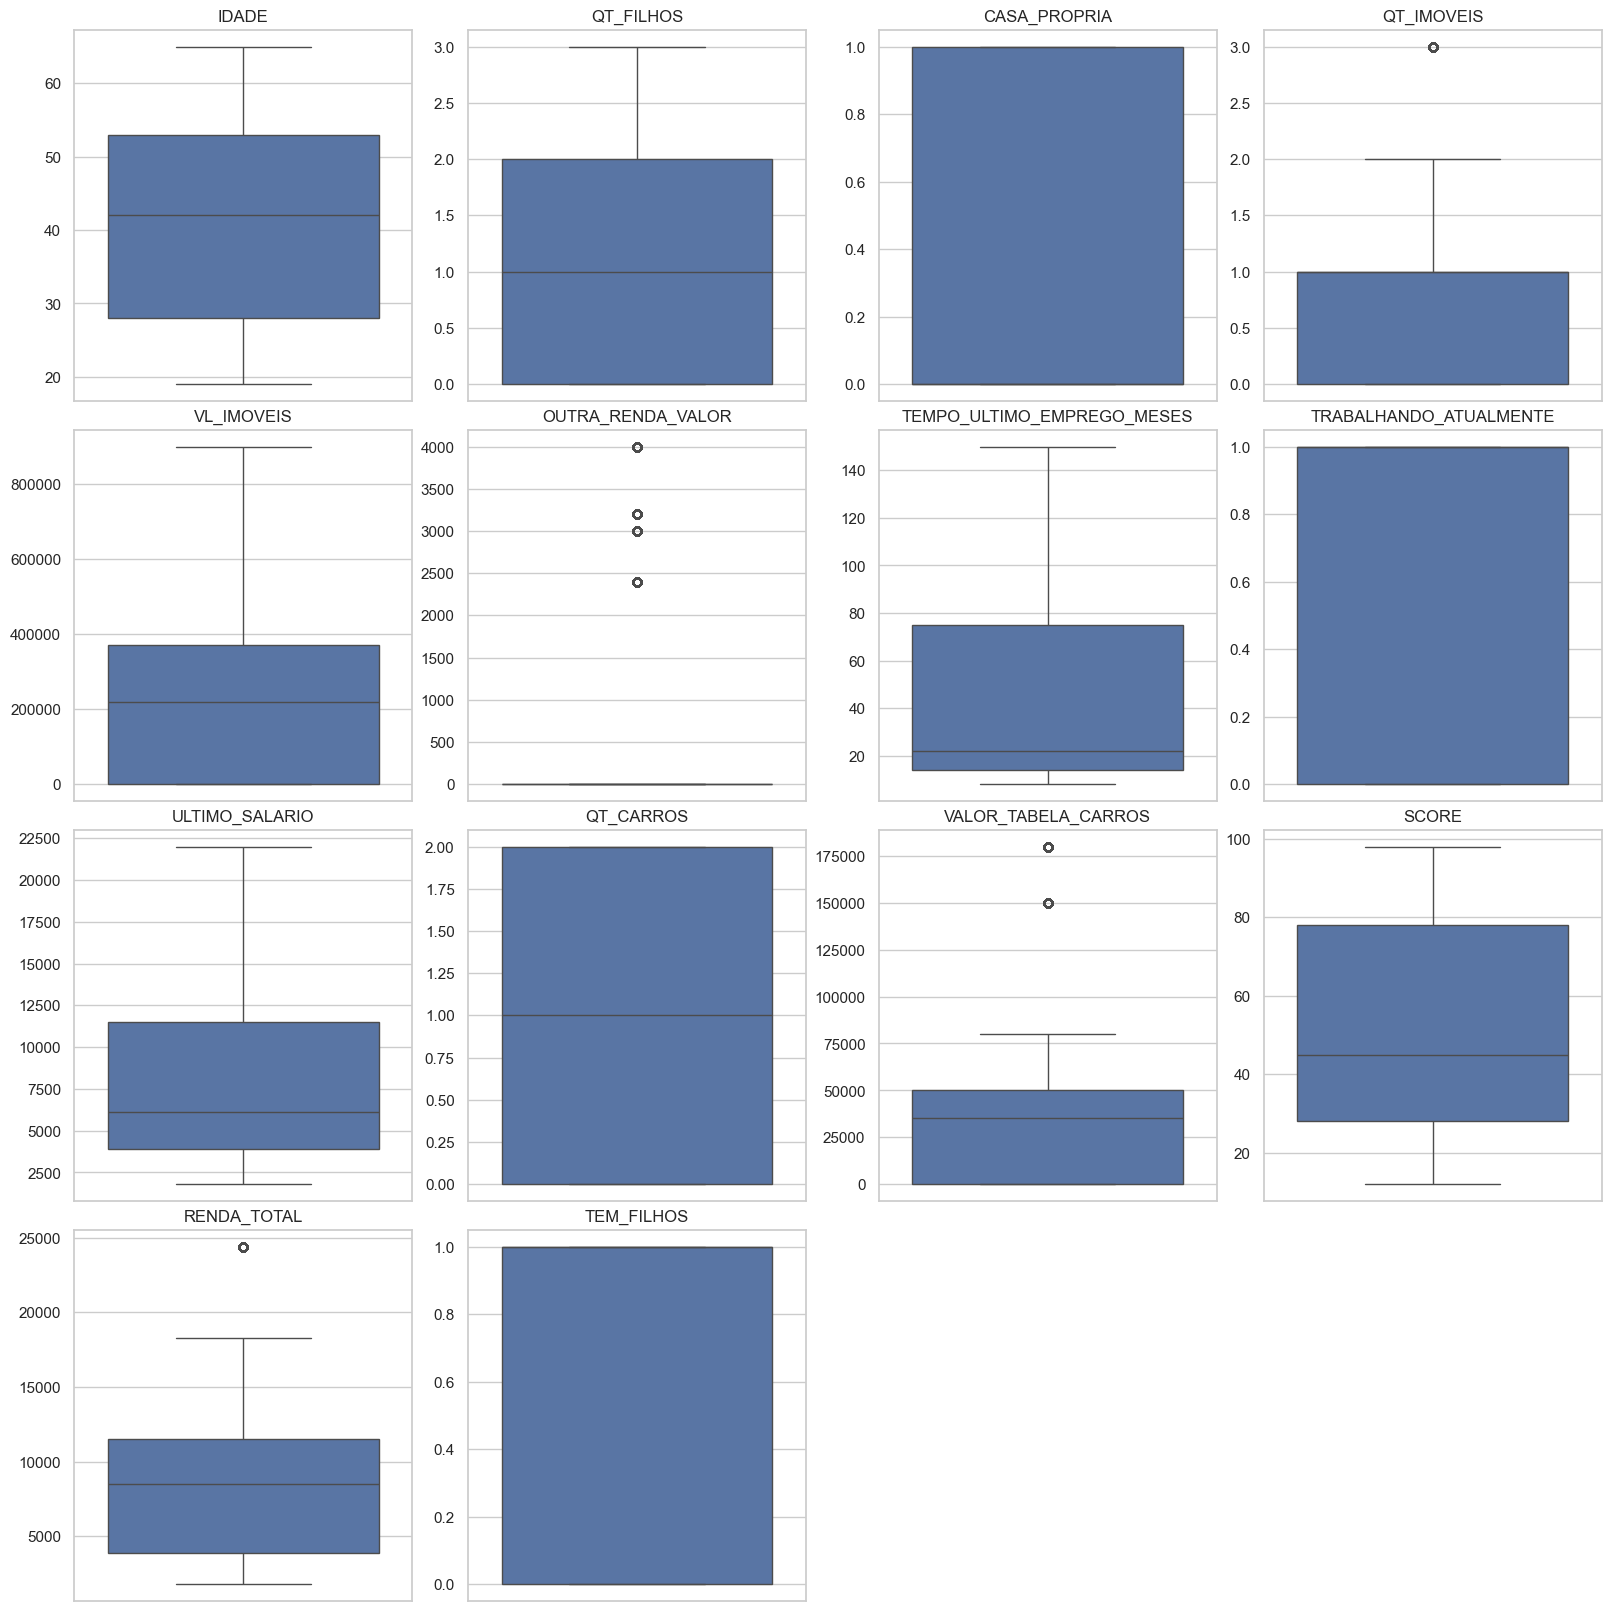

In [34]:
fig_rows = math.ceil(len(numeric_cols) / 4)
fig, axes = plt.subplots(fig_rows, 4, figsize=(16, 4 * fig_rows), constrained_layout=True)
for ax, col in zip(axes.flat, numeric_cols):
    values = collect_values(df, col)
    if values:
        sns.boxplot(y=values, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(numeric_cols):]:
    ax.set_visible(False)
plt.show()


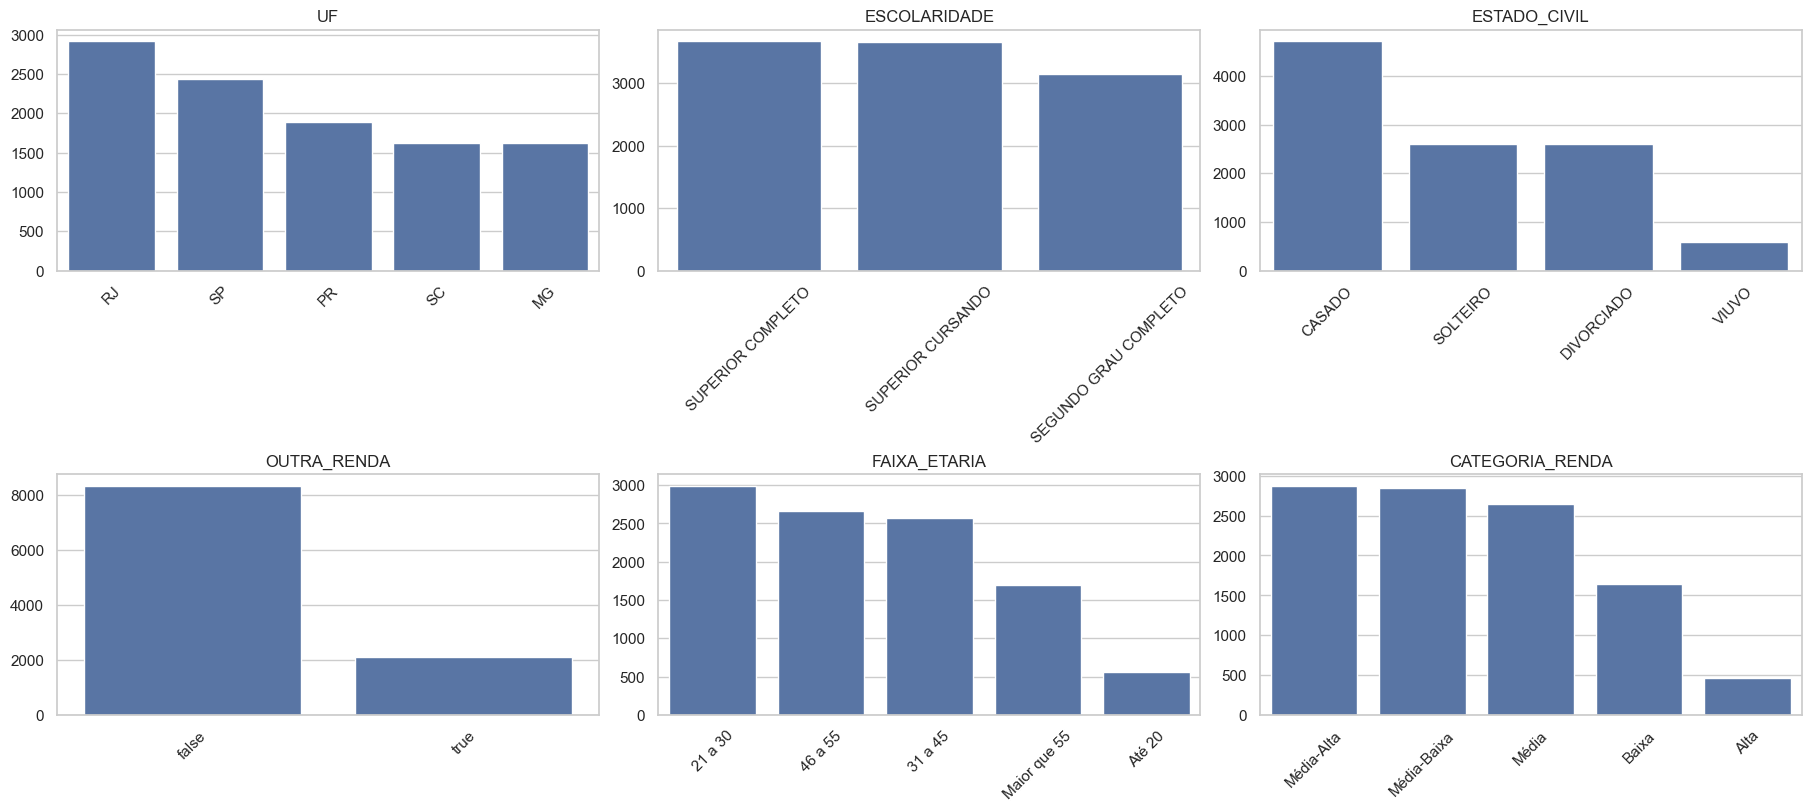

In [35]:
if categorical_cols:
    fig_rows = math.ceil(len(categorical_cols) / 3) or 1
    fig, axes = plt.subplots(fig_rows, 3, figsize=(18, 4 * fig_rows), constrained_layout=True)
    for ax, col in zip(axes.flat, categorical_cols):
        counts = df.groupBy(col).count().orderBy(F.desc("count")).collect()
        labels = [str(row[col]) if row[col] is not None else "NULO" for row in counts]
        values = [row['count'] for row in counts]
        sns.barplot(x=labels, y=values, ax=ax)
        ax.set_title(col)
        ax.tick_params(axis='x', rotation=45)
    for ax in axes.flat[len(categorical_cols):]:
        ax.set_visible(False)
    plt.show()
else:
    print("Não há colunas categóricas para visualizar.")


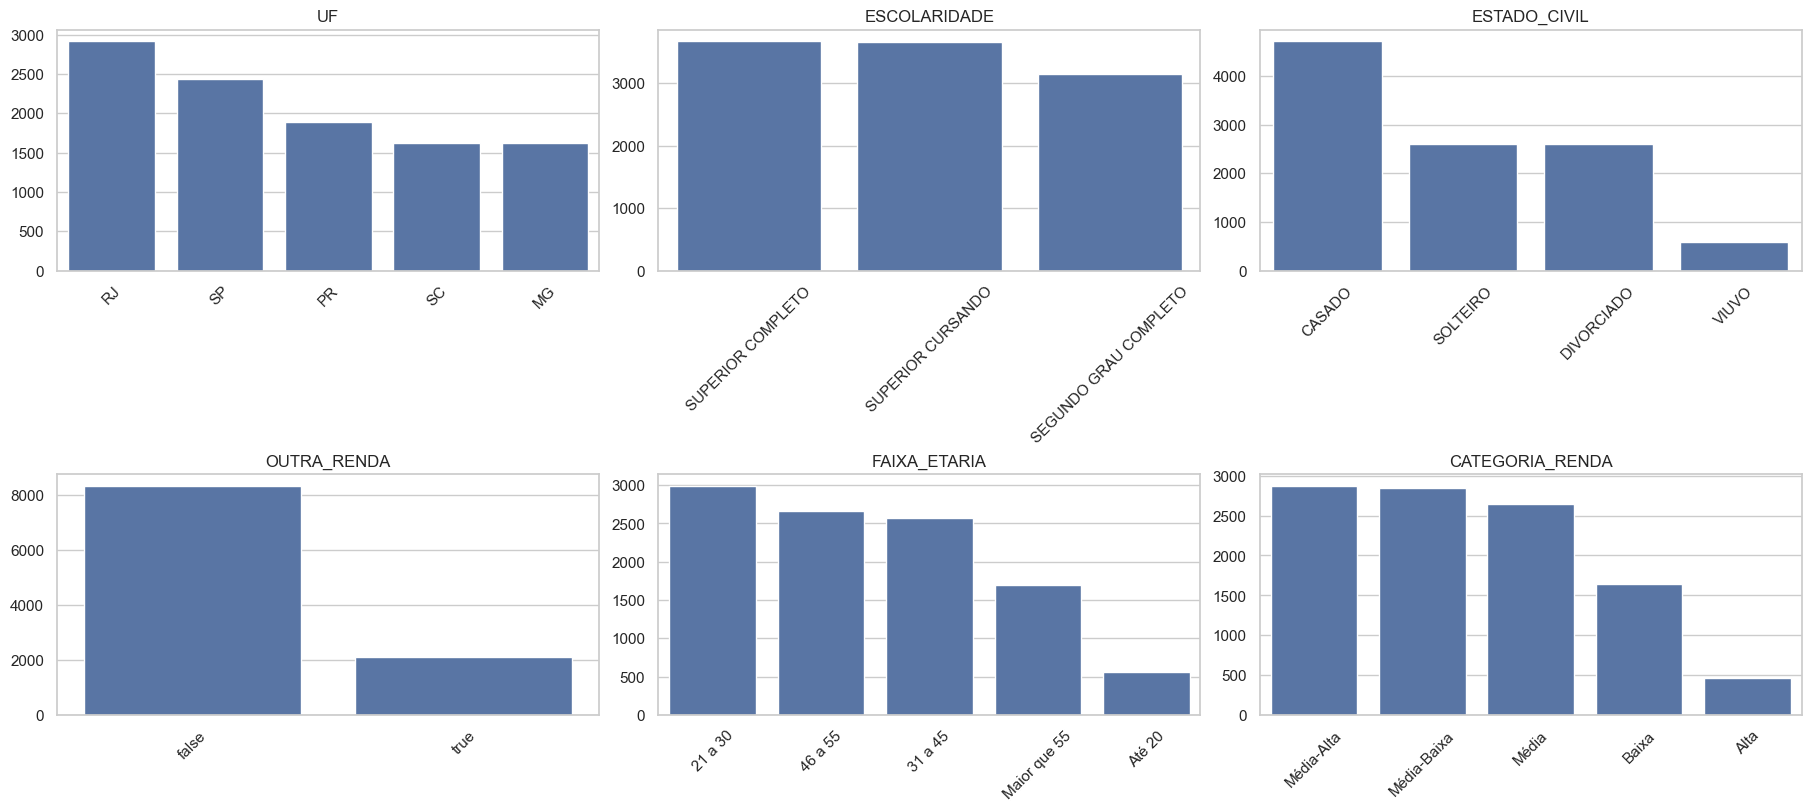

In [36]:
fig_rows = math.ceil(len(categorical_cols) / 3) or 1
fig, axes = plt.subplots(fig_rows, 3, figsize=(18, 4 * fig_rows), constrained_layout=True)
for ax, col in zip(axes.flat, categorical_cols):
    counts = df.groupBy(col).count().orderBy(F.desc("count")).collect()
    labels = [str(row[col]) if row[col] is not None else "NULO" for row in counts]
    values = [row['count'] for row in counts]
    sns.barplot(x=labels, y=values, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
for ax in axes.flat[len(categorical_cols):]:
    ax.set_visible(False)
plt.show()


In [37]:
plt.rcParams["figure.figsize"] = (18, 8)


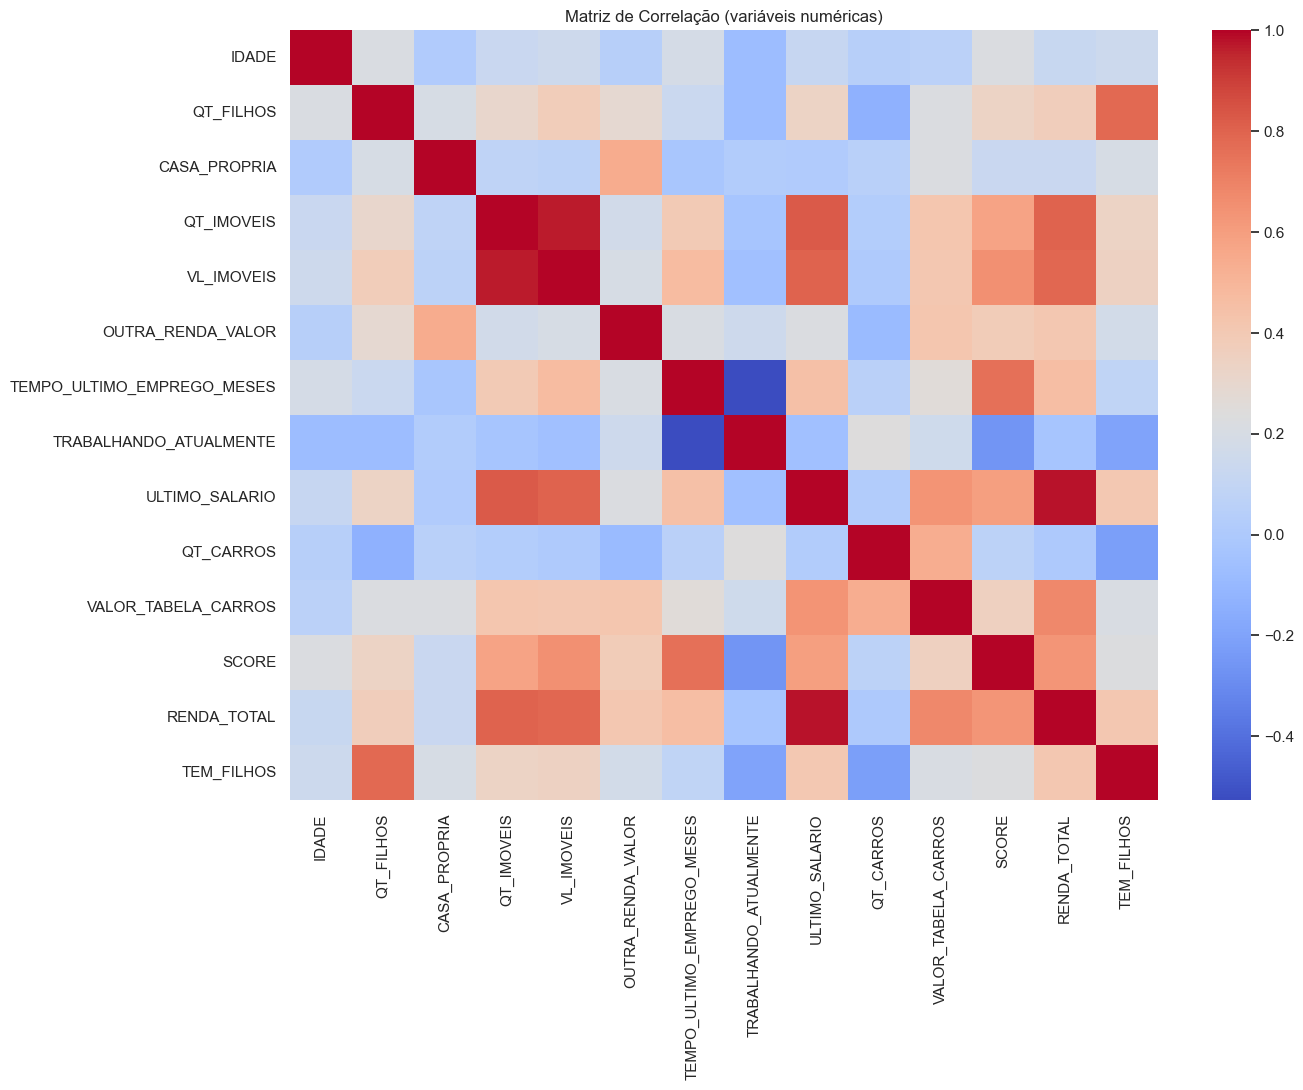

In [38]:
corr_matrix = []
for row_col in numeric_cols:
    row_values = []
    for col_col in numeric_cols:
        corr = df.stat.corr(row_col, col_col)
        row_values.append(corr if corr is not None else 0.0)
    corr_matrix.append(row_values)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", xticklabels=numeric_cols, yticklabels=numeric_cols)
plt.title("Matriz de Correlação (variáveis numéricas)")
plt.show()


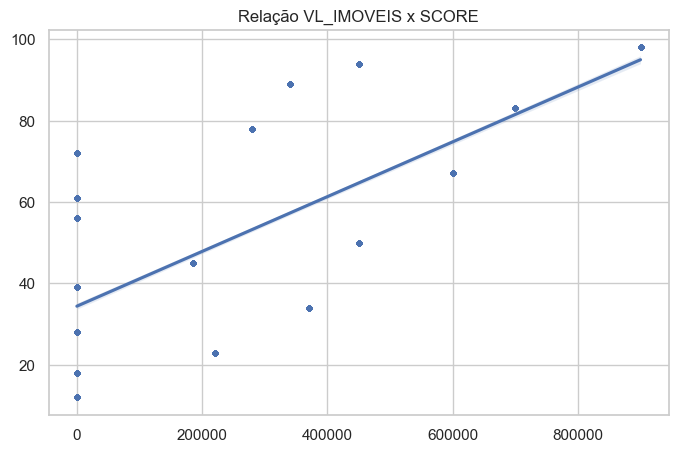

In [39]:
x_vals, y_vals = collect_pairs(df, "VL_IMOVEIS", "SCORE")
plt.figure(figsize=(8, 5))
sns.regplot(x=x_vals, y=y_vals, scatter_kws={"s": 10})
plt.title("Relação VL_IMOVEIS x SCORE")
plt.show()


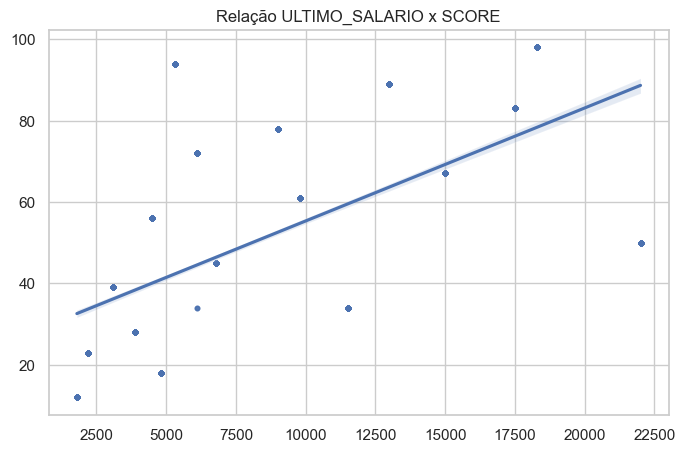

In [40]:
x_vals, y_vals = collect_pairs(df, "ULTIMO_SALARIO", "SCORE")
plt.figure(figsize=(8, 5))
sns.regplot(x=x_vals, y=y_vals, scatter_kws={"s": 10})
plt.title("Relação ULTIMO_SALARIO x SCORE")
plt.show()


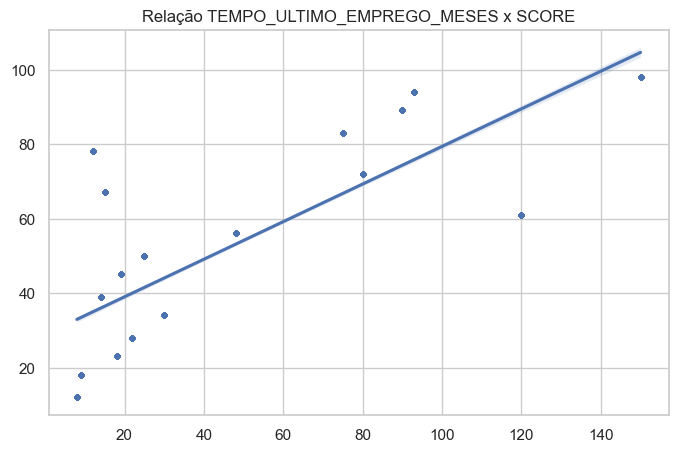

In [41]:
x_vals, y_vals = collect_pairs(df, "TEMPO_ULTIMO_EMPREGO_MESES", "SCORE")
plt.figure(figsize=(8, 5))
sns.regplot(x=x_vals, y=y_vals, scatter_kws={"s": 10})
plt.title("Relação TEMPO_ULTIMO_EMPREGO_MESES x SCORE")
plt.show()


## Processamento dos Dados

In [42]:
target_col = "SCORE"

numeric_features = [
    "IDADE", "QT_FILHOS", "QT_IMOVEIS", "VL_IMOVEIS", "OUTRA_RENDA_VALOR",
    "TEMPO_ULTIMO_EMPREGO_MESES", "ULTIMO_SALARIO", "QT_CARROS",
    "VALOR_TABELA_CARROS", "RENDA_TOTAL"
]

categorical_features = [
    "UF", "ESCOLARIDADE", "ESTADO_CIVIL", "OUTRA_RENDA",
    "FAIXA_ETARIA", "CATEGORIA_RENDA", "TRABALHANDO_ATUALMENTE",
    "CASA_PROPRIA", "TEM_FILHOS"
]

for col in numeric_features + [target_col]:
    if col in df.columns:
        df = df.withColumn(col, F.col(col).cast("double"))

for col in categorical_features:
    if col in df.columns:
        df = df.withColumn(col, F.col(col).cast("string"))

model_columns = [c for c in numeric_features + categorical_features + [target_col] if c in df.columns]
df_model = df.select(*model_columns).dropna()
df_model.cache()
print(f"Registros utilizados para o modelo: {df_model.count()} (após dropna)")


Registros utilizados para o modelo: 10476 (após dropna)


25/11/10 21:22:12 WARN CacheManager: Asked to cache already cached data.


In [43]:
available_categorical = [col for col in categorical_features if col in df_model.columns]
indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="skip")
    for col in available_categorical
]

assembler_inputs = [col for col in numeric_features if col in df_model.columns] + [f"{col}_idx" for col in available_categorical]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features_unscaled")
minmax_scaler = MinMaxScaler(inputCol="features_unscaled", outputCol="features_minmax")
standard_scaler = StandardScaler(inputCol="features_minmax", outputCol="features", withMean=True, withStd=True)
regressor = LinearRegression(featuresCol="features", labelCol=target_col)


In [44]:
pipeline = Pipeline(stages=indexers + [assembler, minmax_scaler, standard_scaler, regressor])


In [ ]:
train_df, test_df = df_model.randomSplit([0.7, 0.3], seed=398)
print(f"Registros treino: {train_df.count()} | Registros teste: {test_df.count()}")


Registros treino: 7463 | Registros teste: 3013


## Criar, avaliar e testar nosso modelo preditivo 

In [46]:
model = pipeline.fit(train_df)
print("Modelo Linear Regression treinado com Spark ML.")


Modelo Linear Regression treinado com Spark ML.


25/11/10 21:22:14 WARN Instrumentation: [12bb9089] regParam is zero, which might cause numerical instability and overfitting.


In [47]:
predictions = model.transform(test_df)
evaluator = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")
r2 = evaluator.evaluate(predictions)
print(f"R² no conjunto de teste: {r2:.4f}")


R² no conjunto de teste: 0.8300
